From the `Bamboo_setup` directory, run the following command:
```bash
jupyter notebook --no-browser --port=8888
```
Copy the URL starting with `http://localhost:8888/`.
When picking the kernel for this notebook, click **Existing Jupyter Server** and paste the URL.
Name your server 'localhost'.
From localhost, select the 'Python 3' kernel.

In [4]:
import sys
from pathlib import Path
BAMBOO_SETUP = Path.cwd()
NN_POSTPROCESSING = BAMBOO_SETUP / 'src' / 'post_processing' / 'NN'
NOTEBOOKS = NN_POSTPROCESSING / 'notebooks'
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window
# pd.set_option('display.max_colwidth', None)  # Allow columns to be fully displayed
%load_ext autoreload

# Setup a data handler

In [14]:
from post_processing.NN.DataHandler import DataHandler
datahandler = DataHandler(
    workdir=Path('/eos/user/a/anunezde/Z_OUTPUT_eos/2022_even_0822/LLR_and_vars_4o5'),
    tree_name='SL_res_2b_x',
    total_inputs= NN_POSTPROCESSING / 'input/8llrs1D.txt'
)
total_df_unprep = datahandler.load_data()
total_df_unprep = datahandler.fix_any_mismatch(total_df_unprep)

	Loading data...
		DY_dl_mll_10to50: 101
		DY_dl_mll_50_0J: 34
		DY_dl_mll_50_1J: 361
		DY_dl_mll_50_2J: 11367
		bbWW_dl: 1153
		bbWW_sl: 2290
		bbtautau: 8848
		WW: 476
		WZ: 588
		ZZ: 68
		Wjets_0J: 13
		Wjets_1J: 105
		Wjets_2J: 5160
		tWminus_dl: 24810
		tWminus_sl: 107698
		tbarWplus_dl: 25198
		tbarWplus_sl: 110913
		TTbar_dl: 601158
		TTbar_sl: 1000000


In [15]:
total_df_unprep

,event,genWeight,bjet0_pt_llr,bjets_dEta_llr,bjets_dPhi_llr,bjets_dR_llr,bjets_mbb_llr,mjj_llr,trijet_mInv_llr,trijet_pt_rat_llr,File,Process
186577,18,3.805950,-0.278,0.401,0.742,1.496,1.167,0.428,0.439,0.014,tbarWplus_dl,tW
13167,32,0.033119,-0.242,0.329,0.937,1.507,0.849,0.393,0.549,1.259,bbWW_sl,HH_bbWW
706510,36,81.103897,-0.322,-0.791,-1.330,-2.183,-2.512,-0.028,0.317,-0.649,TTbar_dl,ttbar
13168,42,0.033119,0.132,0.239,1.084,1.504,0.714,0.130,0.117,-0.098,bbWW_sl,HH_bbWW
11905,58,0.033119,0.109,0.358,0.747,1.493,1.051,-0.491,0.396,-0.674,bbWW_dl,HH_bbWW
...,...,...,...,...,...,...,...,...,...,...,...,...
30323,744899478,83745.546875,-0.288,0.327,-0.377,-0.090,-0.269,-0.151,-0.445,-0.622,Wjets_2J,WJets
30340,745108688,83745.546875,-0.223,0.343,0.757,1.520,0.263,0.193,0.558,-0.775,Wjets_2J,WJets
30318,745244862,83745.546875,-0.219,NaN,0.886,-1.550,-inf,-0.071,-1.004,0.563,Wjets_2J,WJets
30006,745282826,-83745.546875,-0.325,-0.230,0.668,-0.090,0.155,-0.419,-0.551,-0.246,Wjets_2J,WJets


# Inspect preprocessing

In [16]:
def check(df):
    nan_cells = df.isna().sum().sum()
    neg_9999_cells = (df == -9999).sum().sum()
    neg_9_cells = (df == -9).sum().sum()
    pos_9999_cells = (df == 9999).sum().sum()

    print(f"Number of cells with NaN: {nan_cells}")
    print(f"Number of cells with -9999: {neg_9999_cells}")
    print(f"Number of cells with -9: {neg_9_cells}")
    print(f"Number of cells with +9999: {pos_9999_cells}")

In [17]:
total_df_v1 = datahandler.preprocess_data(total_df_unprep, nan_replacement = -9999)
check(total_df_v1)


Preprocessing data ...
After removing events with negative weights:
LLRs were found in the loaded data.
Replacing any nan values with -9999
Preprocessed Total_df:
            event     genWeight  bjet0_pt_llr  bjets_dEta_llr  bjets_dPhi_llr  bjets_dR_llr  bjets_mbb_llr  mjj_llr  trijet_mInv_llr  trijet_pt_rat_llr          File  Process_DY  Process_HH_bbWW  Process_HH_bbtautau  Process_VV  Process_WJets  Process_tW  Process_ttbar
186577         18      3.805950        -0.278           0.401           0.742         1.496          1.167    0.428            0.439              0.014  tbarWplus_dl           0                0                    0           0              0           1              0
13167          32      0.033119        -0.242           0.329           0.937         1.507          0.849    0.393            0.549              1.259       bbWW_sl           0                1                    0           0              0           0              0
706510         36     81.1

In [18]:
total_df_v2 = datahandler.preprocess_data(total_df_unprep, nan_replacement = -9)
check(total_df_v2)


Preprocessing data ...


After removing events with negative weights:
LLRs were found in the loaded data.
Replacing any nan values with -9
Preprocessed Total_df:
            event     genWeight  bjet0_pt_llr  bjets_dEta_llr  bjets_dPhi_llr  bjets_dR_llr  bjets_mbb_llr  mjj_llr  trijet_mInv_llr  trijet_pt_rat_llr          File  Process_DY  Process_HH_bbWW  Process_HH_bbtautau  Process_VV  Process_WJets  Process_tW  Process_ttbar
186577         18      3.805950        -0.278           0.401           0.742         1.496          1.167    0.428            0.439              0.014  tbarWplus_dl           0                0                    0           0              0           1              0
13167          32      0.033119        -0.242           0.329           0.937         1.507          0.849    0.393            0.549              1.259       bbWW_sl           0                1                    0           0              0           0              0
706510         36     81.103897        -0.322        

# Edit DNNModel subclass as necessary

In [20]:
from post_processing.NN.DNNModel import DNNModel
from tensorflow.keras.layers import Input, Masking, Normalization
import numpy as np

class TestDNNModel(DNNModel):
    def input_preprocessing(self, X_train):
        print(f"\tPreprocessing input ...")
        print(f"\t\tThe mask value is: {self.mask_value}")

        ndim = len(X_train.columns)
        input_layer = Input(shape=(ndim, ), name="input")
        masked_inputs = Masking(mask_value=self.mask_value)(input_layer)
        X_train_valid = X_train.replace(self.mask_value, np.nan)

        mean = X_train_valid.mean(axis=0)
        variance = X_train_valid.var(axis=0)
        print(f"Mean:\n{mean}")
        print(f"Variance:\n{variance}")
        normalizer = Normalization(mean=mean, variance=variance, name='normalization')
        normalized_input = normalizer(masked_inputs)        

        return input_layer, normalized_input

# Set up your model config

In [22]:
from post_processing.NN.utils import ModelConfig
model_config = ModelConfig(
    name='multi_HH_ttbar_tW',
    type='multi',
    categorization={"HH": ["HH_bbWW"], "ttbar": ["ttbar"], "tW": ["tW"]},
    training_weight_sf={"HH_bbWW": 1.0, "ttbar": 8.0, "tW": 4.0},
    input_vars='All',
    architecture_in_yml=True,
    residual_network=False,
    hiddenlayers=[
        {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
        # {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4},
        # {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
    ],
    outputlayers=[
        {"type": 'Dense', "units": 3, "kernel_initializer": 'normal', "activation": 'softmax', "act_regularizer": {'l2': 1e-4}, "name": 'output'}
    ],
    compiler={"optimizer": 'adam', "lr": 0.001, "loss": 'categorical_crossentropy'},
    fit={"batch_size": 1024, "epochs": 2, "validation_split": 0.25}
)

# Run DNN

### Version 1: -9999

Initializing model: multi_HH_ttbar_tW


Process_HH_bbWW
Total sum of genWeights for HH_bbWW: 108.30008697509766 
Total sum of sample_weights for HH_bbWW: 1857345.9098510742 
Process_ttbar
Total sum of genWeights for ttbar: 381467648.0 
Total sum of sample_weights for ttbar: 14858771.06210621 
Process_tW
Total sum of genWeights for tW: 8042688.5 
Total sum of sample_weights for tW: 7429384.208231437 
	Model dataframe:
            event   genWeight  bjet0_pt_llr  bjets_dEta_llr  bjets_dPhi_llr  bjets_dR_llr  bjets_mbb_llr  mjj_llr  trijet_mInv_llr  trijet_pt_rat_llr  sample_weight  Class_HH  Class_ttbar  Class_tW
186577         18    3.805950        -0.278           0.401           0.742         1.496          1.167    0.428            0.439              0.014       3.515723         0            0         1
13167          32    0.033119        -0.242           0.329           0.937         1.507          0.849    0.393            0.549              1.259     567.997559         1            0         0
706510         36   81.10

Could not search for non-variable resources. Concrete function internal representation may have changed.


	Saving model info ...
	Evaluating model and predicting ...
{'loss': 0.568661093711853, 'accuracy': 0.8542870283126831, 'precision': 0.8544511795043945, 'recall': 0.8537082672119141, 'auc_roc': 0.9286755323410034, 'auc_pr': 0.8188771605491638, 'f1_score_macro': 0.3122956156730652, 'f1_score_micro': 0.8542870283126831, 'precision_HH': 0.0, 'recall_HH': 0.0, 'precision_ttbar': 0.8550975918769836, 'recall_ttbar': 0.9982479810714722, 'precision_tW': 0.5014792680740356, 'recall_tW': 0.006339648272842169}
11609/11609 [==============================] - 9s 794us/step
	Predictions:
      event  Class_HH  Class_ttbar  Class_tW  Score_HH  Score_ttbar  Score_tW
0  22503358       0.0          1.0       0.0  0.080485     0.628068  0.291447
1  57385234       0.0          1.0       0.0  0.062441     0.637170  0.300389
2  17528158       0.0          1.0       0.0  0.021501     0.652011  0.326489
3  11242832       0.0          1.0       0.0  0.106354     0.612166  0.281479
4    915896       0.0         

({'loss': 0.568661093711853,
  'accuracy': 0.8542870283126831,
  'precision': 0.8544511795043945,
  'recall': 0.8537082672119141,
  'auc_roc': 0.9286755323410034,
  'auc_pr': 0.8188771605491638,
  'f1_score_macro': 0.3122956156730652,
  'f1_score_micro': 0.8542870283126831,
  'precision_HH': 0.0,
  'recall_HH': 0.0,
  'precision_ttbar': 0.8550975918769836,
  'recall_ttbar': 0.9982479810714722,
  'precision_tW': 0.5014792680740356,
  'recall_tW': 0.006339648272842169},
 array([[1.53139357e-03, 9.96937213e-01, 1.53139357e-03],
        [1.89069275e-05, 9.98922305e-01, 1.05878794e-03],
        [3.74020534e-05, 9.93622950e-01, 6.33964805e-03]]),
 array([[0.11111111, 0.00175573, 0.00147929],
        [0.66666667, 0.85494829, 0.49704142],
        [0.22222222, 0.14329598, 0.50147929]]),
 ['HH', 'ttbar', 'tW'])

2024-10-22 02:13:32.741302: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2024-10-22 02:13:32.741788: I tensorflow/core/grappler/clusters/single_machine.cc:357] Starting new session
2024-10-22 02:13:32.859475: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2024-10-22 02:13:32.859605: I tensorflow/core/grappler/clusters/single_machine.cc:357] Starting new session


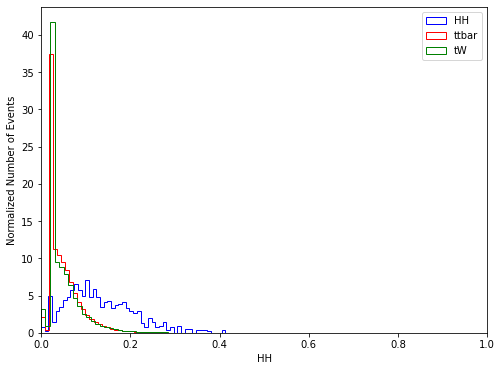

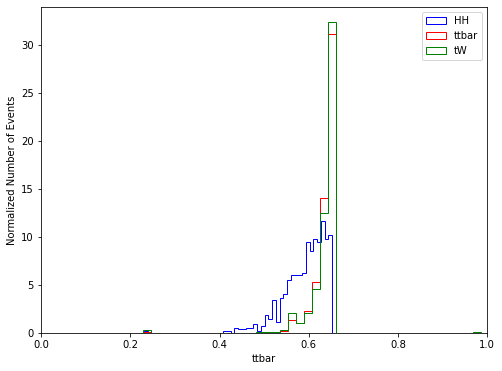

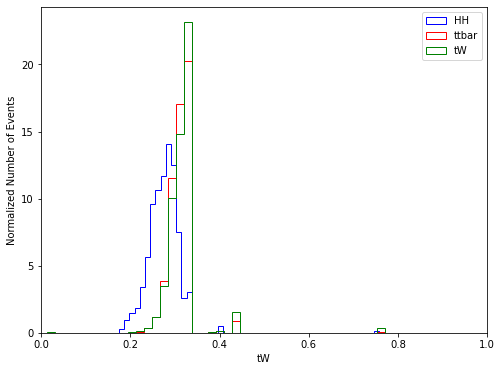

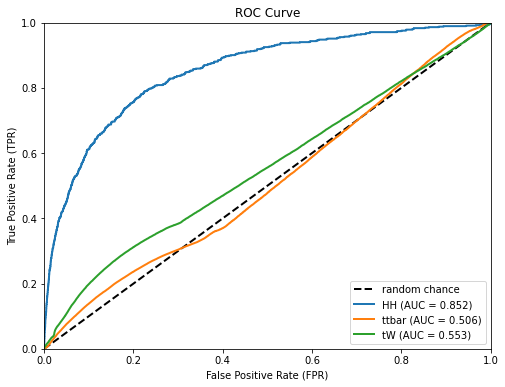

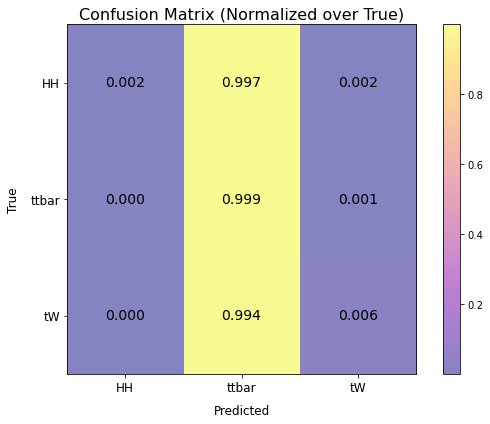

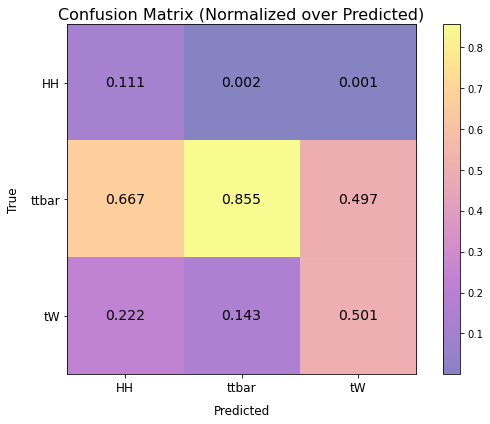

In [23]:
DNN1 = TestDNNModel(model_config=model_config, modeldir= NOTEBOOKS/'model_m9999')
DNN1.mask_value = -9999
DNN1.Run(total_df_v1, fixed_random_seed=True)

### Version 2: -9

Initializing model: multi_HH_ttbar_tW
Process_HH_bbWW
Total sum of genWeights for HH_bbWW: 108.30008697509766 
Total sum of sample_weights for HH_bbWW: 1857345.9098510742 
Process_ttbar
Total sum of genWeights for ttbar: 381467648.0 
Total sum of sample_weights for ttbar: 14858771.06210621 
Process_tW
Total sum of genWeights for tW: 8042688.5 
Total sum of sample_weights for tW: 7429384.208231437 
	Model dataframe:
            event   genWeight  bjet0_pt_llr  bjets_dEta_llr  bjets_dPhi_llr  bjets_dR_llr  bjets_mbb_llr  mjj_llr  trijet_mInv_llr  trijet_pt_rat_llr  sample_weight  Class_HH  Class_ttbar  Class_tW
186577         18    3.805950        -0.278           0.401           0.742         1.496          1.167    0.428            0.439              0.014       3.515723         0            0         1
13167          32    0.033119        -0.242           0.329           0.937         1.507          0.849    0.393            0.549              1.259     567.997559         1           

Could not search for non-variable resources. Concrete function internal representation may have changed.


	Saving model info ...
	Evaluating model and predicting ...
{'loss': 0.564342737197876, 'accuracy': 0.8407838940620422, 'precision': 0.847491979598999, 'recall': 0.8039572238922119, 'auc_roc': 0.9310119152069092, 'auc_pr': 0.8383893966674805, 'f1_score_macro': 0.3597586154937744, 'f1_score_micro': 0.840783953666687, 'precision_HH': 0.058370042592287064, 'recall_HH': 0.08116386085748672, 'precision_ttbar': 0.8613604307174683, 'recall_ttbar': 0.931323766708374, 'precision_tW': 0.363995224237442, 'recall_tW': 0.05690722540020943}
11609/11609 [==============================] - 10s 873us/step
	Predictions:
      event  Class_HH  Class_ttbar  Class_tW  Score_HH  Score_ttbar  Score_tW
0  22503358       0.0          1.0       0.0  0.089151     0.633340  0.277509
1  57385234       0.0          1.0       0.0  0.056952     0.681711  0.261337
2  17528158       0.0          1.0       0.0  0.006558     0.597520  0.395922
3  11242832       0.0          1.0       0.0  0.138444     0.582418  0.279138
4

({'loss': 0.564342737197876,
  'accuracy': 0.8407838940620422,
  'precision': 0.847491979598999,
  'recall': 0.8039572238922119,
  'auc_roc': 0.9310119152069092,
  'auc_pr': 0.8383893966674805,
  'f1_score_macro': 0.3597586154937744,
  'f1_score_micro': 0.840783953666687,
  'precision_HH': 0.058370042592287064,
  'recall_HH': 0.08116386085748672,
  'precision_ttbar': 0.8613604307174683,
  'recall_ttbar': 0.931323766708374,
  'precision_tW': 0.363995224237442,
  'recall_tW': 0.05690722540020943},
 array([[0.20520674, 0.78866769, 0.00612557],
        [0.0088642 , 0.97382966, 0.01730614],
        [0.01058478, 0.93045088, 0.05896434]]),
 array([[3.81440364e-02, 1.43331070e-03, 4.62481212e-04],
        [8.00740108e-01, 8.60094960e-01, 6.34986704e-01],
        [1.61115855e-01, 1.38471729e-01, 3.64550815e-01]]),
 ['HH', 'ttbar', 'tW'])

2024-10-22 02:16:06.755572: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2024-10-22 02:16:06.755686: I tensorflow/core/grappler/clusters/single_machine.cc:357] Starting new session
2024-10-22 02:16:07.186467: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2024-10-22 02:16:07.186613: I tensorflow/core/grappler/clusters/single_machine.cc:357] Starting new session


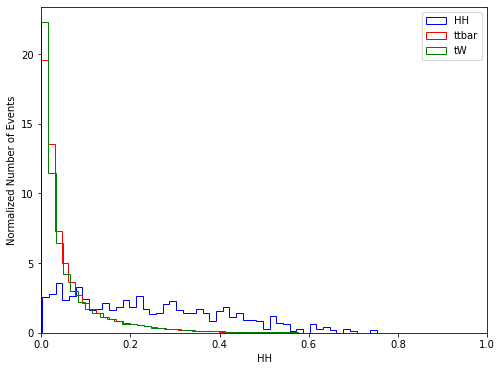

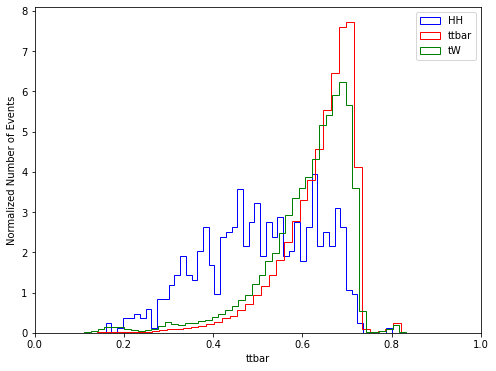

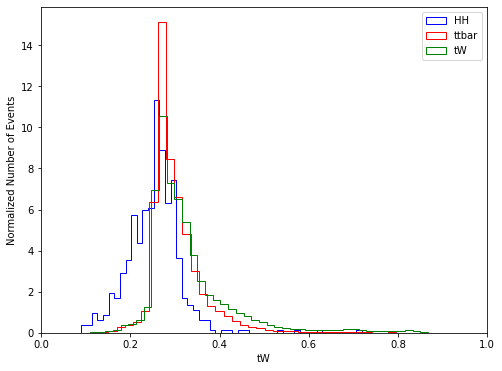

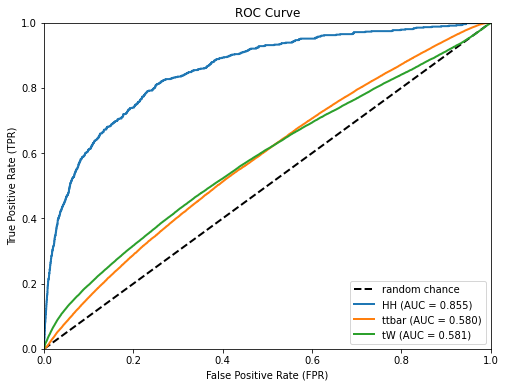

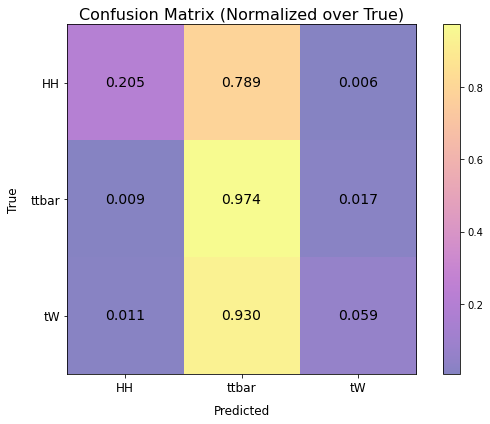

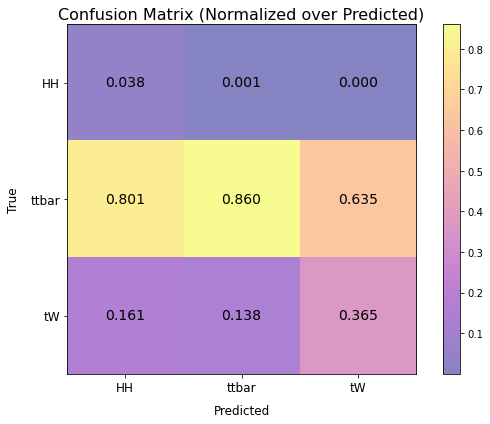

In [24]:
DNN2 = TestDNNModel(model_config=model_config, modeldir= NOTEBOOKS/'model_m9')
DNN2.mask_value = -9
DNN2.Run(total_df_v2, fixed_random_seed=True)